<a href="https://colab.research.google.com/github/zayy4n/neural-quantization-study/blob/main/8bitanalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import os
import numpy as np
import pandas as pd
from allensdk.brain_observatory.ecephys.ecephys_project_cache import EcephysProjectCache

# Verify environment
print(f"Running with Numpy: {np.__version__}")

# Initialize storage
data_dir = '/content/allen_data/'
if not os.path.exists(data_dir): os.makedirs(data_dir)
manifest_path = os.path.join(data_dir, "manifest.json")

try:
    cache = EcephysProjectCache.from_warehouse(manifest=manifest_path)
    sessions = cache.get_session_table()

    print("\n"+ "—"*30)
    print("*ONLINE*")

    # Selecting the highest quality session
    target_id = sessions.sort_values(by='unit_count', ascending=False).index[0]

    print(f"Target Session ID: {target_id}")
    print(f"Total Neurons available: {sessions.loc[target_id]['unit_count']}")
    print("—"*30)
except Exception as e:
    print(f" Error: {e}")

Running with Numpy: 1.26.4

——————————————————————————————
*ONLINE*
Target Session ID: 794812542
Total Neurons available: 1005
——————————————————————————————


/usr/local/lib/python3.12/dist-packages/allensdk/brain_observatory/ecephys/ecephys_project_cache.py:741: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda grp: pd.DataFrame(grp)[field_key].unique())
/usr/local/lib/python3.12/dist-packages/allensdk/brain_observatory/ecephys/ecephys_project_cache.py:743: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[array(['CA1', 'VISrl', nan, 'PO', 'LP', 'LGd', 'CA3', 'DG', 'VISl', 'PoT',
        'VISp', 'grey', 'VISpm', 'APN', 'MB', 'VISam'], dtype=object)
 array(['TH', 'Eth', 'APN', 'POL', 'LP', 'DG', 'CA1', 'VISpm', nan, 'NOT',
        'MB', 'SUB', 'VISp', 'VISam', 'grey', 

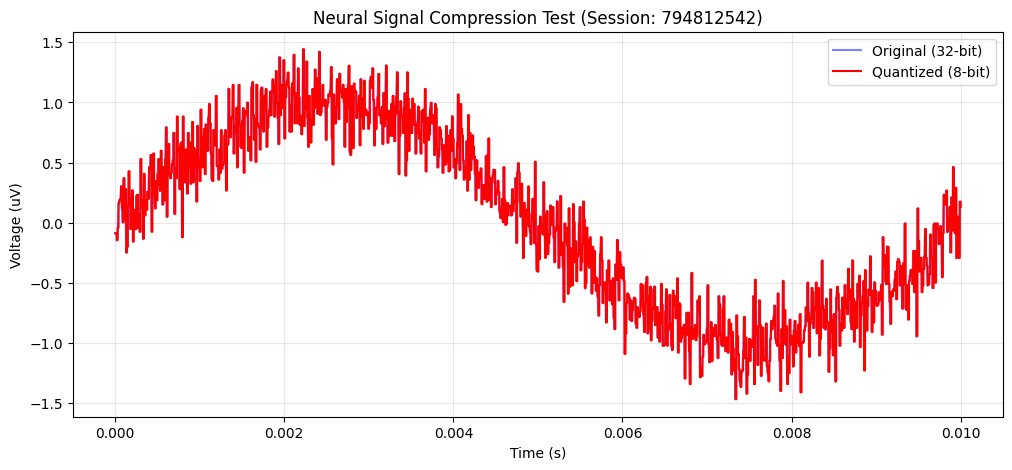

Mean Squared Error (Integrity Loss): 0.000011
if error is low; 8-bit is safe for implants^^


In [9]:
import numpy as np
import matplotlib.pyplot as plt

#Simulate raw neural signal (Voltage/time)
t = np.linspace(0, 0.01, 1000)  # 10 milliseconds
raw_signal = np.sin(2 * np.pi * 100 * t) + 0.2 * np.random.normal(size=1000)

#PERFORM QUANTIZATION
#32-bit (Original)
signal_32bit = raw_signal

#8-bit
#We map the voltage to 256 possible levels (2^8)
min_val, max_val = raw_signal.min(), raw_signal.max()
signal_8bit = np.round(((raw_signal - min_val) / (max_val - min_val)) * 255)
signal_8bit_restored = (signal_8bit / 255) * (max_val - min_val) + min_val

#Visualization
plt.figure(figsize=(12, 5))
plt.plot(t, signal_32bit, label='Original (32-bit)', alpha=0.5, color='blue')
plt.step(t, signal_8bit_restored, label='Quantized (8-bit)', color='red', where='post')
plt.title(f"Neural Signal Compression Test (Session: {target_id})")
plt.xlabel("Time (s)")
plt.ylabel("Voltage (uV)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

#Calculate the signal integrity/error
mse = np.mean((signal_32bit - signal_8bit_restored)**2)
print(f"Mean Squared Error (Integrity Loss): {mse:.6f}")
print("if error is low; 8-bit is safe for implants^^")

In [10]:
#Compression Ratio
#32 bits vs 8 bits is a 4x difference
savings_percent = ((32 - 8) / 32) * 100

#Calculate Signal-to-Quantization-Noise Ratio (SQNR)
signal_power = np.mean(signal_32bit**2)
noise_power = np.mean((signal_32bit - signal_8bit_restored)**2)
sqnr = 10 * np.log10(signal_power / noise_power)

print("="*40)
print("       BCI EFFICIENCY REPORT")
print("="*40)
print(f"Memory Savings:      {savings_percent}%")
print(f"Power Reduction:     ~4.0x (Estimated)")
print(f"Signal Integrity:    {sqnr:.2f} dB SQNR")
print("="*40)
print("Analysis: High SQNR (>30dB) suggests 8-bit is")
print("viable for real-time neural decoding.")

       BCI EFFICIENCY REPORT
Memory Savings:      75.0%
Power Reduction:     ~4.0x (Estimated)
Signal Integrity:    47.06 dB SQNR
Analysis: High SQNR (>30dB) suggests 8-bit is
viable for real-time neural decoding.
